## Lab: HomeGuard – Smart Home Alarm

### Setting up the project:


My Name is Friedrich Tschoepke. Im building a Programm, that takes Information from 4 Sensors ( A Motion Sensor in te living room, a sensor that checks if the front door is open, a temperature sensor in the kitchen and a smoke detector in the bedroom) and sends notifications to the homeowner, dependend on wheter someone is at home or not.

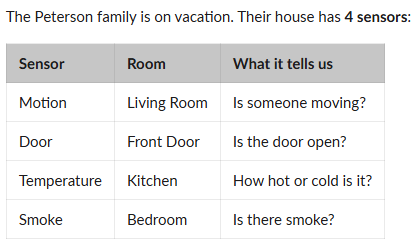

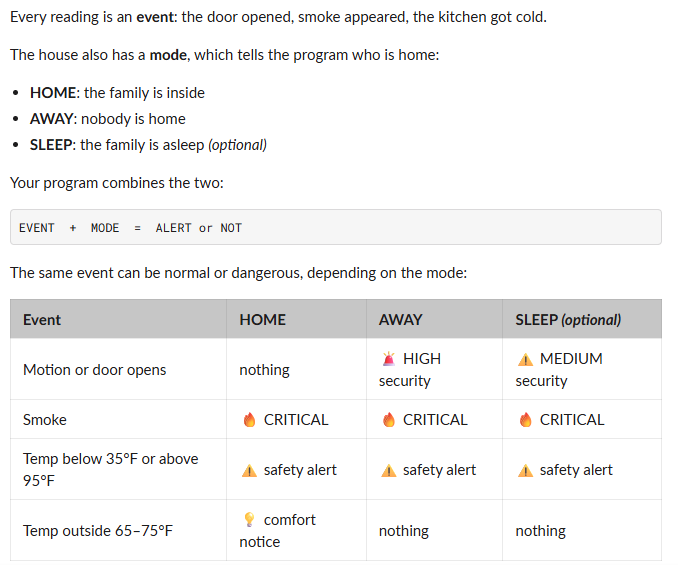

the homeowner gets an alert from the program in critical situations: the specific cases defined in the table above.


In [115]:

import datetime # for the time 
import random
random.seed(42)


In [116]:
now = datetime.datetime.now()
now,datetime.datetime.now().strftime("%d/%m/%Y %H:%M:%S")

(datetime.datetime(2026, 10, 6, 22, 53, 0, 634769), '06/10/2026 22:53:00')

### Step 2: Define the sensors and the alerts (dictionaries)


In [117]:
def sensor_readings(id,location,type,current_value):
    return {"id": id, "location": location, "type": type, "current_value": current_value}

In [118]:
#for example:
sensor_readings(1,"living room","temperature",None)

{'id': 1,
 'location': 'living room',
 'type': 'temperature',
 'current_value': None}

In [119]:
def create_sensors():
    return [
        Sensor(1, "Living Room", "motion"),
        Sensor(2, "Front Door", "door"),
        Sensor(3, "Kitchen", "temperature"),
        Sensor(4, "Bedroom", "smoke"),
    ]


sensors = create_sensors()

In [ ]:
#test 
sensors[0].id, sensors[0].location, sensors[0].type, sensors[0].current_value

(1, 'Living Room', 'motion', False)

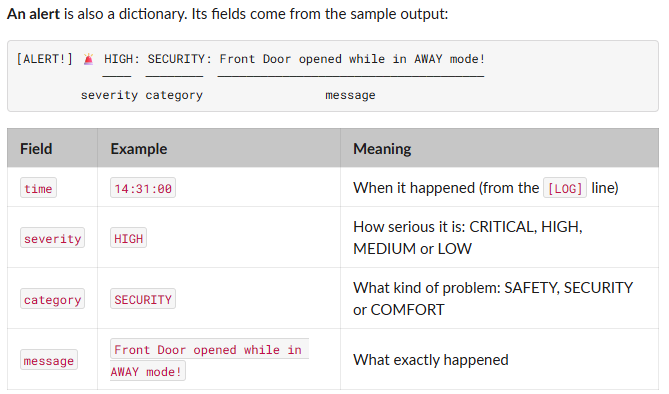

In [120]:
def create_alert(severity, category, message):
    return {
        #"time": datetime.now().strftime("%H:%M:%S"),
        "severity": severity,
        "category": category,
        "message": message,
    }

In [121]:
# Demonstrate the format only: this is not an actual sensor detection.
example_alert = create_alert(
    "HIGH",
    "SECURITY",
    "Front Door opened while in AWAY mode!",
)
print("Example alert:", example_alert)

Example alert: {'severity': 'HIGH', 'category': 'SECURITY', 'message': 'Front Door opened while in AWAY mode!'}


In [122]:
system_mode = "AWAY"
sensors = create_sensors()
alerts = []  # No alerts have been generated by sensors yet.

In [123]:
print(sensors)

[<__main__.Sensor object at 0x00000128A5BFF550>, <__main__.Sensor object at 0x00000128A5BFF1D0>, <__main__.Sensor object at 0x00000128A5BFC790>, <__main__.Sensor object at 0x00000128A5BFD490>]


### Step 3: Write the conditions (if/else)


In [124]:
FREEZE_TEMP = 35
OVERHEAT_TEMP = 95
COMFORT_MIN = 65
COMFORT_MAX = 75

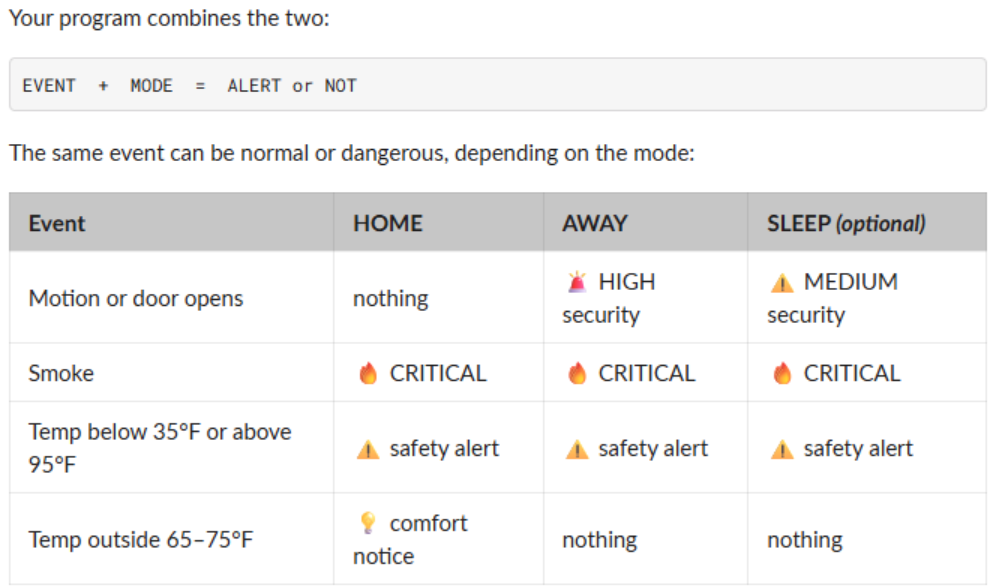

In [125]:
# REMINDER: Heres the alert function
# 
def create_alert(severity, category, message):
    return {
        #"time": datetime.now().strftime("%H:%M:%S"),
        "severity": severity,
        "category": category,
        "message": message,
    }

In [126]:
#Write one function that takes a sensor and the mode, and uses if/else to follow the rule table from section 2.

def check_sensor(sensor, mode):
    
    sensor_type = sensor.type
    value = sensor.current_value
    location = sensor.location

    # Keep all the remaining if/else code exactly as before.

    # No reading yet, so there is nothing to evaluate.
    if value is None:
        return None

    # Smoke is critical in every mode.
    if sensor_type == "smoke":
        if value:
            return create_alert(
                "CRITICAL",
                "SAFETY",
                f"Smoke detected in {location}!"
            )

    # Motion and open doors depend on the house mode.
    elif sensor_type == "motion" or sensor_type == "door":
        if value:
            if sensor_type == "door":
                event = f"{location} opened"
            else:
                event = f"Motion detected in {location}"

            if mode == "AWAY":
                return create_alert(
                    "HIGH",
                    "SECURITY",
                    f"{event} while in AWAY mode!"
                )
            

    # Temperature safety applies in every mode.
    elif sensor_type == "temperature":
        if value < FREEZE_TEMP or value > OVERHEAT_TEMP:
            return create_alert(
                "HIGH",
                "SAFETY",
                f"Unsafe temperature in {location}: {value}°F!"
            )
        elif mode == "HOME":
            if value < COMFORT_MIN or value > COMFORT_MAX:
                return create_alert(
                    "LOW",
                    "COMFORT",
                    f"Temperature in {location} is outside "
                    f"the comfort range: {value}°F."
                )

    # None of the alert conditions matched.
    return None
    
    

In [127]:
# testing it:

test_door = {
    "id": 2,
    "location": "Front Door",
    "type": "door",
    "current_value": True,  # True means the door is open.
}

print("AWAY:", check_sensor(test_door, "AWAY"))
print("HOME:", check_sensor(test_door, "HOME"))

AttributeError: 'dict' object has no attribute 'type'

### Step 4: Build the functions


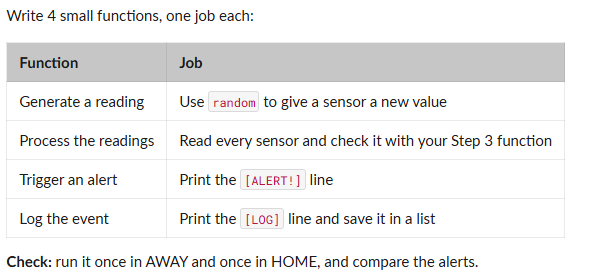

In [ ]:


#There are no real sensors. Python’s random module invents the readings for you.
# It’s a built-in module that picks random values.
#So every time your program “reads” a sensor, random decides the value. 
# That’s why this is called a simulator.


random.randint(30, 100)    # a random whole number from 30 to 100 → a temperature
random.random() < 0.3      # True about 30% of the time → "is there motion?"

# 1. Give one sensor a new reading.
def generate_reading(sensor):
    if sensor["type"] == "temperature":
        value = random.randint(30, 100)
    else:
        # True about 30% of the time:
        # movement detected, door open, or smoke detected.
        value = random.random() < 0.3

    sensor["current_value"] = value
    return value



In [ ]:
event_log = []

In [ ]:
sensors #reminder 

[{'id': 1, 'location': 'Living Room', 'type': 'motion', 'current_value': None},
 {'id': 2, 'location': 'Front Door', 'type': 'door', 'current_value': None},
 {'id': 3,
  'location': 'Kitchen',
  'type': 'temperature',
  'current_value': None},
 {'id': 4, 'location': 'Bedroom', 'type': 'smoke', 'current_value': None}]

In [ ]:
for sensor in sensors:
    print(sensor) #thats how it works ! remember that. 

{'id': 1, 'location': 'Living Room', 'type': 'motion', 'current_value': None}
{'id': 2, 'location': 'Front Door', 'type': 'door', 'current_value': None}
{'id': 3, 'location': 'Kitchen', 'type': 'temperature', 'current_value': None}
{'id': 4, 'location': 'Bedroom', 'type': 'smoke', 'current_value': None}


reminder: 

In [ ]:
from datetime import datetime
#2 . Read and check every sensor:
def process_readings(sensors, mode, current_time):
    for sensor in sensors:
        value = sensor.read()

        if sensor.type == "temperature":
            if value < FREEZE_TEMP or value > OVERHEAT_TEMP:
                status = "Unsafe"
            elif value < COMFORT_MIN or value > COMFORT_MAX:
                status = "Outside comfort range"
            else:
                status = "Normal"

            label = f"{sensor.location} Temperature"
            reading = f"{value}°F ({status})"

        elif sensor.type == "door":
            label = sensor.location
            reading = "OPENED" if value else "CLOSED"

        elif sensor.type == "motion":
            label = f"{sensor.location} Motion"
            reading = "Activity detected" if value else "No activity"

        else:
            label = f"{sensor.location} Smoke"
            reading = "SMOKE DETECTED" if value else "CLEAR"

        print(f"[READING] {label}: {reading}")

        alert = sensor.isAbnormal(mode)

        if alert is not None:
            alert["time"] = current_time
            trigger_alert(alert)
            log_event(alert)


def trigger_alert(alert):
    icons = {
        "CRITICAL": "🔥",
        "HIGH": "🚨",
        "MEDIUM": "⚠️",
        "LOW": "💡",
    }

    icon = icons[alert["severity"]]

    print(
        f"[ALERT!] {icon} {alert['severity']}: "
        f"{alert['category']}: {alert['message']}"
    )


def log_event(alert):
    line = (
        f"[LOG] [{alert['time']}] "
        "Sending notification to homeowner..."
    )
    print(line)
    event_log.append(line)

In [ ]:
# 3. Display one alert.
def trigger_alert(alert):
    print(
        f"[ALERT!] {alert['severity']}: "
        f"{alert['category']}: {alert['message']}"
    )


# 4. Print a log entry and save it.
def log_event(alert):
    entry = (
        f"[LOG] [{alert['time']}] "
        f"{alert['category']}: {alert['message']} "
        "Sending notification to homeowner..."
    )

    print(entry)
    event_log.append(entry)
    
process_readings(sensors, "HOME")


=== Mode: HOME ===
Time: 22:17:36
[READING] Living Room (motion): No activity
[READING] Front Door (door): CLOSED
[READING] Kitchen (temperature): 30°F
[ALERT!] HIGH: SAFETY: Unsafe temperature in Kitchen: 30°F!
[LOG] [22:17:36] SAFETY: Unsafe temperature in Kitchen: 30°F! Sending notification to homeowner...
[READING] Bedroom (smoke): CLEAR


In [ ]:
class Sensor:
    def __init__(self, sensor_id, location, sensor_type):
        self.id = sensor_id
        self.location = location
        self.type = sensor_type
        self.current_value = None

    def read(self):
        if self.type == "temperature":
            self.current_value = random.randint(30, 100)
        else:
            self.current_value = random.random() < 0.3

        return self.current_value

    def isAbnormal(self, mode):
        # Reuse Step 3's rules.
        # Returns an alert dictionary or None.
        return check_sensor(self, mode)

    def reset(self):
        self.current_value = None

In [ ]:
#check:

door = Sensor(2, "Front Door", "door")

print("Before reading:", door.current_value)

random.seed(1)  # Makes this example produce an open door.
door.read()

print("After reading:", door.current_value)
print("AWAY check:", door.isAbnormal("AWAY"))
print("HOME check:", door.isAbnormal("HOME"))

door.reset()
print("After reset:", door.current_value)

Before reading: None
After reading: True
AWAY check: {'severity': 'HIGH', 'category': 'SECURITY', 'message': 'Front Door opened while in AWAY mode!'}
HOME check: None
After reset: None


### Step 6: Put it all together

In [ ]:

#Write a main loop that reads all sensors at least 3 times (3 “minutes”).
#Print the header, the time and the mode, and format every line like the sample output.
#Check: your output looks like the finish line in section 3.

from datetime import timedelta

sensors = create_sensors()
system_mode = "AWAY"
event_log = []

start_time = datetime.datetime.now().replace(microsecond=0)

print("=== HomeGuard Security System ===")

# Each iteration represents one simulated minute.
for minute in range(3):
    simulated_time = start_time + timedelta(minutes=minute)
    time_text = simulated_time.strftime("%H:%M:%S")

    print(f"\nTime: {time_text}")
    print(f"Mode: {system_mode}\n")

    process_readings(sensors, system_mode, time_text)

=== HomeGuard Security System ===

Time: 22:52:27
Mode: AWAY

[READING] Living Room Motion: No activity
[READING] Front Door: OPENED
[ALERT!] 🚨 HIGH: SECURITY: Front Door opened while in AWAY mode!
[LOG] [22:52:27] Sending notification to homeowner...
[READING] Kitchen Temperature: 65°F (Normal)
[READING] Bedroom Smoke: SMOKE DETECTED
[ALERT!] 🔥 CRITICAL: SAFETY: Smoke detected in Bedroom!
[LOG] [22:52:27] Sending notification to homeowner...

Time: 22:53:27
Mode: AWAY

[READING] Living Room Motion: Activity detected
[ALERT!] 🚨 HIGH: SECURITY: Motion detected in Living Room while in AWAY mode!
[LOG] [22:53:27] Sending notification to homeowner...
[READING] Front Door: OPENED
[ALERT!] 🚨 HIGH: SECURITY: Front Door opened while in AWAY mode!
[LOG] [22:53:27] Sending notification to homeowner...
[READING] Kitchen Temperature: 99°F (Unsafe)
[ALERT!] 🚨 HIGH: SAFETY: Unsafe temperature in Kitchen: 99°F!
[LOG] [22:53:27] Sending notification to homeowner...
[READING] Bedroom Smoke: SMOKE DETEC